In [1]:
import contextily as cx
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

from wpp import data
from wpp.utils import project_root

# config
sns.set_theme(style="ticks")
pl.Config.set_engine_affinity("streaming")

polars.config.Config

In [2]:
DATA_PATH = project_root() / "data"
CSV_PATH = DATA_PATH / "weekly-patterns-plus-sample.csv"
PARQUET_DIR_PATH = DATA_PATH / "2025-weekly-patterns-plus"
US_PATH = DATA_PATH / "us-states.json"

In [3]:
lf = data.load_weekly_patterns_plus_parquet(PARQUET_DIR_PATH).filter(pl.col("ISO_COUNTRY_CODE") == "US").filter(pl.col("BRAND").str.contains("tarbuck"))
states = gpd.read_file(US_PATH)
states = states.loc[states["name"] != "Alaska"]
lf.head().collect()

BRAND,BUCKETED_DWELL_TIMES,CITY,CLOSE_DATE,DATE_RANGE_END,DATE_RANGE_START,DEVICE_TYPE,DISTANCE_FROM_HOME,FOOTPRINT_ID,ID_STORE,ISO_COUNTRY_CODE,IS_DISTRIBUTOR,LATITUDE,LOCATION_NAME,LONGITUDE,MEDIAN_DWELL,MSA_CODE,NAICS_CODE,OPEN_DATE,PERSISTENT_ID,PERSISTENT_ID_STORE,POI_CBG,POSTAL_CODE,REGION,RELATED_SAME_DAY_BRAND,RELATED_SAME_WEEK_BRAND,STREET_ADDRESS,SUB_CATEGORY,TICKER,TOP_CATEGORY,VISITOR_COUNTRY_OF_ORIGIN,VISITOR_COUNTS,VISITOR_DAYTIME_CBGS,VISITOR_HOME_AGGREGATION,VISITOR_HOME_CBGS,VISITS_BY_DAY,VISITS_BY_EACH_HOUR,VISIT_COUNTS
str,str,str,date,datetime[ms],datetime[ms],str,f64,"decimal[38,0]",str,str,bool,f64,str,f64,f64,"decimal[38,0]",str,date,str,str,str,str,str,str,str,str,str,str,str,str,"decimal[38,0]",str,str,str,str,str,"decimal[38,0]"
"""Starbucks""","""{""<5"":1456, ""5-20"":0, ""21-60"":…","""Independence""",2038-01-01,2025-01-12 00:00:00,2025-01-06 00:00:00,"""{""android"":1159,""ios"":297}""",13449.0,8944539021998105699,"""1252799""","""US""",false,41.395607,"""Starbucks Corporation""",-81.641619,5.0,17460,"""722515""",1970-01-01,"""A1_SBUX""","""1252799""","""390351561011""","""44131-2320""","""OH""","""{""Mall"":1175,""Western Union"":8…","""{""Mall"":1410,""Western Union"":1…","""6901 Rockside Road""","""Snack and Nonalcoholic Beverag…","""SBUX""","""Restaurants and Other Eating P…","""{""US"":1456}""",1456,"""{""390351561011"":684,""390351561…","""{""39035156101"":485,""3903515610…","""{""390351561011"":403,""390351561…","""[165,154,201,271,248,273,143]""","""[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0…",1456
"""Starbucks""","""{""<5"":1674, ""5-20"":86, ""21-60""…","""Phoenix""",2038-01-01,2025-01-12 00:00:00,2025-01-06 00:00:00,"""{""ios"":1005,""android"":700}""",5705.0,8692503206056869823,"""1254054""","""US""",false,33.479104,"""Starbucks Corporation""",-111.984398,2.0,38060,"""722515""",2012-07-19,"""A1_SBUX""","""1254054""","""040131113001""","""85018""","""AZ""","""{""Freshpet"":1705,""Fry's Food &…","""{""Freshpet"":1705,""Fry's Food &…","""4505 East Thomas Road""","""Snack and Nonalcoholic Beverag…","""SBUX""","""Restaurants and Other Eating P…","""{""US"":1705}""",1705,"""{""040131113001"":252,""040131112…","""{""04013111300"":314,""0401311370…","""{""040131113001"":124,""040131137…","""[248,237,236,271,284,309,226]""","""[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0…",1811
"""Starbucks""","""{""<5"":2583, ""5-20"":341, ""21-60…","""North Brunswick""",2038-01-01,2025-01-12 00:00:00,2025-01-06 00:00:00,"""{""android"":1412,""ios"":1110}""",8021.0,8842905721922200480,"""1252300""","""US""",false,40.435342,"""Starbucks Corporation""",-74.504114,6.0,35620,"""722515""",2014-10-21,"""A1_SBUX""","""1252300""","""340230062081""","""08902""","""NJ""","""{""Freshpet"":2522,""Target"":2522…","""{""Freshpet"":2522,""Target"":2522…","""101 Grand Avenue""","""Snack and Nonalcoholic Beverag…","""SBUX""","""Restaurants and Other Eating P…","""{""US"":2522}""",2522,"""{""340230062074"":212,""340230062…","""{""34023006205"":402,""3402300610…","""{""340230062054"":176,""340230061…","""[519,367,355,460,378,713,666]""","""[0,0,0,0,0,0,0,0,0,0,0,38,38,0…",3459
"""Starbucks""","""{""<5"":2997, ""5-20"":604, ""21-60…","""Lexington""",2038-01-01,2025-01-12 00:00:00,2025-01-06 00:00:00,"""{""ios"":2779,""android"":974}""",10669.0,6895773435483088799,"""5069762""","""US""",false,37.978242,"""Starbucks Corporation""",-84.527983,9.0,30460,"""722515""",2017-08-06,"""A1_SBUX""","""5069762""","""210670041031""","""40517""","""KY""","""{""Mall"":3557,""The Centennial C…","""{""Mall"":3753,""Freshpet"":3525,""…","""4049 Finn Way""","""Snack and Nonalcoholic Beverag…","""SBUX""","""Restaurants and Other Eating P…","""{""US"":3753}""",3753,"""{""210670008011"":401,""210670041…","""{""21067004210"":334,""2106700410…","""{""210670042102"":253,""210670041…","""[248,403,591,661,603,737,785]""","""[0,0,0,0,13,25,13,0,25,13,25,0…",4027
"""Starbucks""",null,"""Liberty Lake""",2038-01-01,2025-01-12 00:00:00,2025-01-06 00:00:00,null,6654.0,9033381304357814329,

In [4]:
poi_metadata = (
    lf.select("ID_STORE", "LOCATION_NAME", "REGION", "ISO_COUNTRY_CODE", "LONGITUDE", "LATITUDE")
    .group_by("ID_STORE")
    .agg(pl.all().exclude("ID_STORE").first())
    .collect()
)

<Axes: xlabel='NUM_POIS', ylabel='REGION'>

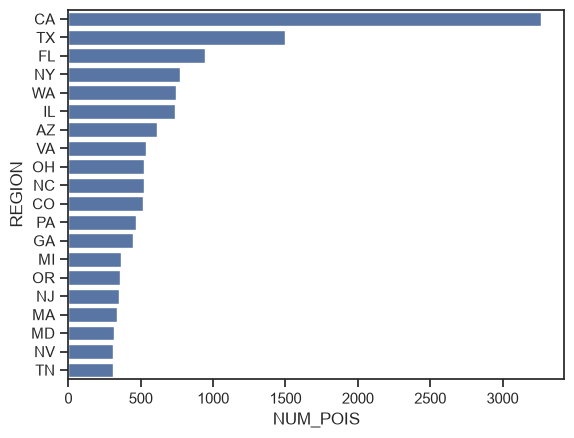

In [5]:
top_pois = (poi_metadata
    .group_by("REGION", "ISO_COUNTRY_CODE")
    .agg(pl.len().alias("NUM_POIS"))
    .sort("NUM_POIS")
    .top_k(20, by="NUM_POIS")
)
sns.barplot(top_pois, y="REGION", x="NUM_POIS")

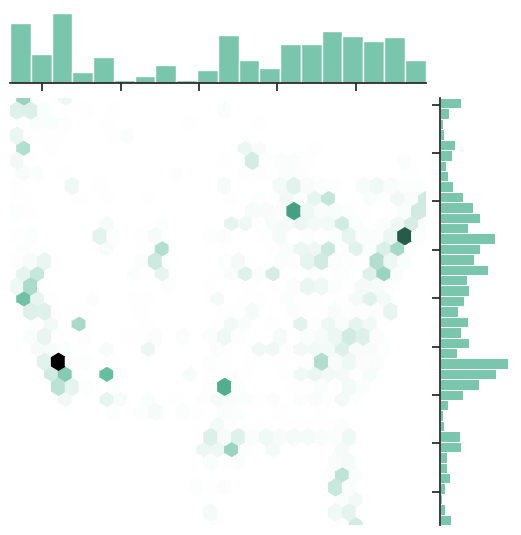

In [6]:
xcol = "LONGITUDE"
ycol = "LATITUDE"
xlim = (poi_metadata[xcol].quantile(0.01), poi_metadata[xcol].quantile(0.99))
ylim = (poi_metadata[ycol].quantile(0.01), poi_metadata[ycol].quantile(0.99))
ax_grid = sns.jointplot(
    data=poi_metadata.filter(pl.col(xcol).is_between(*xlim), pl.col(ycol).is_between(*ylim)),
    x=xcol, 
    y=ycol, 
    kind="hex",
    color="#4CB391",
    xlim=xlim,
    ylim=ylim,
)
ax_grid.ax_joint.set_axis_off()

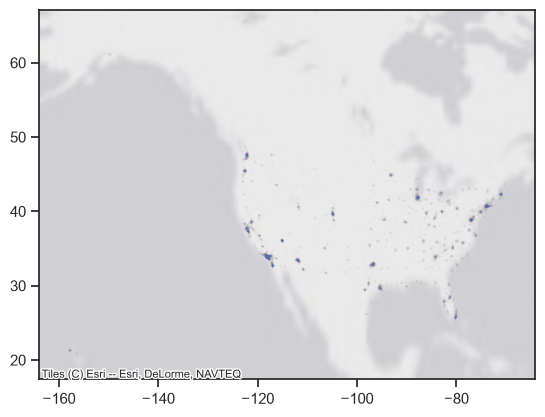

In [7]:
fig, ax = plt.subplots()
ax.scatter(poi_metadata["LONGITUDE"], poi_metadata["LATITUDE"], s=.1, alpha=.01)
minx, miny, maxx, maxy = states.total_bounds
#ax.set_xlim(minx, maxx)
#ax.set_ylim(miny, maxy)
cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.Esri.WorldGrayCanvas, zoom=1)

In [8]:
visitors_by_poi = (
    lf
        .group_by("ID_STORE", "REGION")
        .agg(pl.col("VISITOR_COUNTS").sum())
        .sort(pl.col("VISITOR_COUNTS"))
        .collect()
)

Text(0.5, 1.0, 'CCDF of POI Visitor Counts')

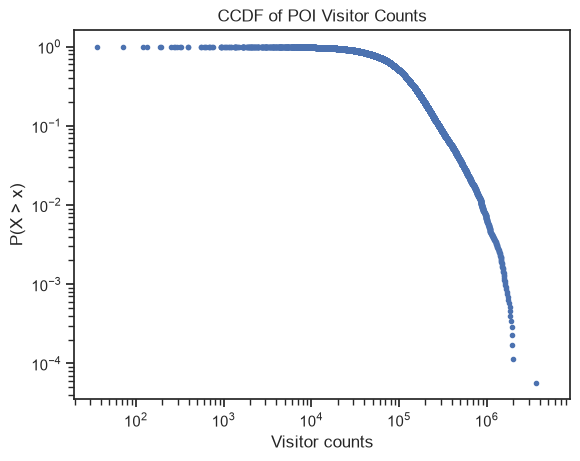

In [9]:
series = visitors_by_poi["VISITOR_COUNTS"].to_numpy()
n = len(series)
# CCDF: P(X > x) for each sorted value
# For the i-th smallest value (1-indexed), the fraction of points
# strictly greater than it is (n - i) / n
ccdf = 1.0 - (np.arange(1, n + 1) / n)

fig, ax = plt.subplots()
ax.scatter(series, ccdf, marker=".", linestyle="none")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Visitor counts")
ax.set_ylabel("P(X > x)")
ax.set_title("CCDF of POI Visitor Counts")

Text(0, 0.5, '#Visitors')

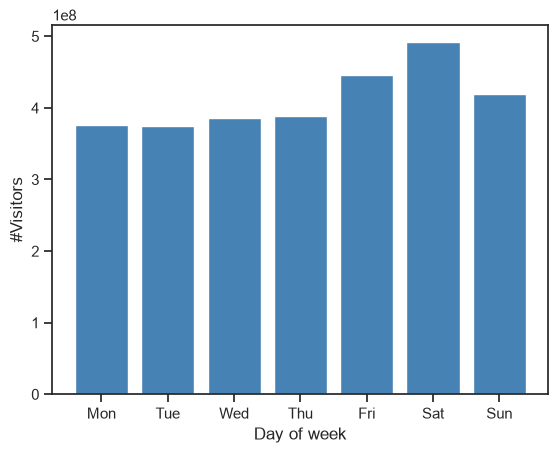

In [12]:
dtype = pl.List(pl.UInt32)
day_sum = (
    lf.select(pl.col("VISITS_BY_DAY").str.json_decode(dtype).list.to_array(7))
    .collect()
    .to_numpy()
    .sum(axis=0)
)[0]
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax = plt.subplots()
ax.bar(day_names, day_sum, color="steelblue")
ax.set_xlabel("Day of week")
ax.set_ylabel("#Visitors")

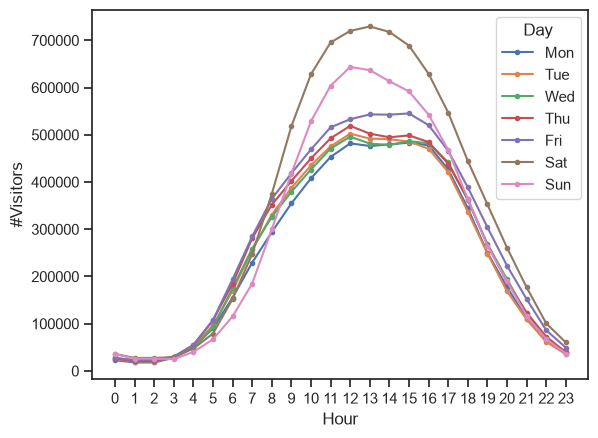

In [13]:
dtype = pl.List(pl.UInt32)
hour_sum = (
    lf
    .filter(pl.col("VISITS_BY_EACH_HOUR").is_not_null())
    #.filter(pl.col("VISITS_BY_EACH_HOUR") != "")
    .limit(10_100)
    .select(pl.col("VISITS_BY_EACH_HOUR").str.json_decode(dtype).list.to_array(168))
    .collect()
    .to_numpy()
    .sum(axis=0)
)[0]

n = hour_sum.shape[0]

hours_per_day = 24
n_days = n // hours_per_day  # 7

x = np.arange(hours_per_day)
fig, ax = plt.subplots()

day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

for i in range(n_days):
    start = i * hours_per_day
    end = start + hours_per_day
    day_data = hour_sum[start:end]
    label = day_names[i] if i < len(day_names) else f"Day {i + 1}"
    ax.plot(x, day_data, label=label, marker="o", markersize=3)

ax.set_xticks(x)
ax.set_xlabel("Hour")
ax.set_ylabel("#Visitors")
ax.legend(title="Day")

In [14]:
print(lf.group_by("TOP_CATEGORY").len().sort("len").top_k(20, by="len").collect().to_numpy())

[['Restaurants and Other Eating Places' 879792]]
